# 멀티 에이전트 협업 네트워크

이 튜토리얼에서는 **멀티 에이전트 네트워크**를 LangGraph를 활용하여 구현하는 방법을 다룹니다. 멀티 에이전트 네트워크는 복잡한 작업을 여러 개의 전문화된 에이전트들로 나누어 처리하는 "분할 정복" 접근 방식을 사용하는 아키텍처입니다.

이를 통해 단일 에이전트가 많은 도구를 비효율적으로 사용하는 문제를 해결하고, 각 에이전트가 자신의 전문 분야에서 효과적으로 문제를 해결하도록 합니다.

> 📖 **참고 문서**: [LangChain Multi-Agent](https://docs.langchain.com/oss/python/langchain/multi-agent/)

본 튜토리얼은 AutoGen 논문에서 영감을 받아, LangGraph를 활용하여 이러한 멀티 에이전트 네트워크를 구축하는 방법을 단계별로 살펴봅니다.

---

## 왜 멀티 에이전트 네트워크인가?

단일 에이전트는 특정 도메인 내에서 일정 수의 도구를 사용할 때 효율적일 수 있습니다. 그러나 한 에이전트가 너무 많은 도구를 다루면 다음과 같은 문제가 발생합니다.

1. 도구 사용 로직이 복잡해집니다.
2. 에이전트가 한 번에 처리해야 할 정보 양이 증가하여 비효율적입니다.

"분할 정복" 접근을 사용하면 각 에이전트는 특정 업무나 전문성 영역에 집중할 수 있고, 전체 작업이 네트워크 형태로 나뉘어 처리됩니다. 각 에이전트는 자신이 잘하는 일을 처리하고, 필요 시 해당 업무를 다른 전문 에이전트에게 위임하거나 도구를 적절히 활용합니다.

---

## 주요 내용

이 튜토리얼에서는 다음 내용을 학습합니다.

- **에이전트 생성**: 에이전트를 정의하고, 이를 LangGraph 그래프의 노드로 설정하는 방법
- **도구 정의**: 에이전트가 사용할 도구를 정의하고 노드로 추가하는 방법
- **그래프 생성**: 에이전트와 도구를 연결하여 멀티 에이전트 네트워크 그래프를 구성하는 방법
- **상태 정의**: 그래프 상태를 정의하고, 각 에이전트의 동작에 필요한 상태 정보를 관리하는 방법
- **엣지 로직 정의**: 에이전트 결과에 따라 다른 에이전트나 도구로 분기하는 로직을 설정하는 방법
- **그래프 실행**: 구성된 그래프를 호출하고 실제 작업을 수행하는 방법

## 환경 설정

LangGraph 튜토리얼을 시작하기 전에 필요한 환경을 설정합니다. `dotenv`를 사용하여 API 키를 로드하고, `langchain_teddynote`의 로깅 기능을 활성화하여 LangSmith에서 실행 추적을 확인할 수 있도록 합니다.

LangSmith 추적을 활성화하면 그래프 실행 과정을 시각적으로 디버깅할 수 있어, 개발 및 문제 해결에 큰 도움이 됩니다.

아래 코드는 환경 변수를 로드하고 LangSmith 프로젝트를 설정합니다.

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다.
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangGraph-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-Tutorial


## 모델 설정

멀티 에이전트 시스템에서 사용할 LLM 모델을 설정합니다. `init_chat_model` 함수는 모델 이름만으로 자동으로 적절한 provider(Anthropic, OpenAI 등)를 선택하여 초기화해주는 편의 함수입니다. 별도의 provider 설정 없이 모델 이름만 지정하면 되므로, provider 변경 시 모델 이름만 수정하면 됩니다.

> 📖 **참고 문서**: [LangChain Chat Models](https://docs.langchain.com/oss/python/langchain/chat-models.md)

아래 코드는 모델을 초기화합니다.

In [3]:
from langchain.chat_models import init_chat_model

# OpenAI 키를 사용하는 경우 gpt-5.2, gpt-4.1-mini 등으로 변경할 수 있습니다.
model = init_chat_model("claude-sonnet-4-5")

print(f"사용 모델: {model.model}")

사용 모델: claude-sonnet-4-5


## 상태 정의

멀티 에이전트 시스템에서 에이전트들이 정보를 공유하기 위한 상태(State)를 정의합니다. `MessagesState`는 내부적으로 `add_messages` 리듀서가 적용된 `messages` 필드를 포함하고 있어, 새 메시지가 기존 메시지 목록에 자동으로 추가됩니다.

아래 코드는 에이전트 상태를 정의합니다.

In [4]:
from langgraph.graph import MessagesState

# MessagesState는 내부적으로 다음과 같이 정의되어 있습니다:
# class MessagesState(TypedDict):
#     messages: Annotated[list, add_messages]

print("MessagesState 사용 준비 완료")

MessagesState 사용 준비 완료


## 도구 정의

에이전트가 사용할 도구들을 정의합니다. 이 튜토리얼에서는 두 가지 도구를 사용합니다.

- **TavilySearch**: 인터넷에서 정보를 검색하는 도구입니다. Research Agent가 필요한 정보를 검색할 때 사용합니다.
- **python_repl_tool**: Python 코드를 실행하는 도구입니다. Chart Generator Agent가 차트를 생성할 때 사용합니다.

아래 코드는 Tavily 검색 도구와 Python 코드 실행 도구를 정의합니다.

In [5]:
import io
import sys
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool

# Tavily 검색 도구 정의 (최대 5개 결과 반환)
tavily_tool = TavilySearch(max_results=5)


def run_python_code(code: str) -> str:
    """Python 코드를 실행하고 stdout 출력을 반환합니다."""
    old_stdout = sys.stdout
    sys.stdout = buffer = io.StringIO()
    try:
        exec(code, {})
    except Exception as e:
        sys.stdout = old_stdout
        return f"Error: {repr(e)}"
    sys.stdout = old_stdout
    return buffer.getvalue()


@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute to generate your chart."],
):
    """Python 코드를 실행합니다. 값의 출력을 보려면 print(...)를 사용해야 합니다."""
    try:
        # 주어진 코드를 실행하고 결과 반환
        result = run_python_code(code)
    except BaseException as e:
        return f"Failed to execute code. Error: {repr(e)}"
    # 실행 성공 시 결과와 함께 성공 메시지 반환
    result_str = f"Successfully executed:\n```python\n{code}\n```\nStdout: {result}"
    return (
        result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
    )

## 에이전트 생성

### Research Agent

Research Agent는 `TavilySearch` 도구를 사용하여 웹에서 정보를 검색하는 에이전트입니다. 이 에이전트는 필요한 정보를 리서치하는 역할을 담당합니다.

`create_agent`는 모델과 도구를 결합하여 에이전트를 생성하는 함수입니다. 에이전트는 도구를 사용하여 작업을 수행하고, 다른 에이전트와 협업할 수 있습니다.

먼저 시스템 프롬프트를 생성하는 헬퍼 함수를 정의합니다. 아래 코드는 협업 에이전트를 위한 시스템 프롬프트 생성 함수를 정의합니다.

In [6]:
def make_system_prompt(suffix: str) -> str:
    """협업 에이전트를 위한 시스템 프롬프트를 생성합니다."""
    return (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{suffix}"
    )

`create_agent`는 `system_prompt` 파라미터를 사용하여 에이전트의 동작을 정의합니다. 또한 `name` 파라미터로 에이전트의 이름을 지정할 수 있습니다.

아래 코드는 Research Agent를 생성하고 노드 함수를 정의합니다.

In [7]:
from langchain_core.messages import HumanMessage
from langchain.agents import create_agent

# Research Agent 생성
research_agent = create_agent(
    model,
    tools=[tavily_tool],
    system_prompt=make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    ),
)


def research_node(state: MessagesState) -> MessagesState:
    """Research Agent 노드 함수입니다."""
    result = research_agent.invoke(state)

    # 마지막 메시지를 HumanMessage로 변환
    last_message = HumanMessage(
        content=result["messages"][-1].content, name="researcher"
    )
    return {
        # Research Agent의 메시지 목록 반환
        "messages": [last_message],
    }

### Chart Generator Agent

Chart Generator Agent는 `PythonREPL` 도구를 사용하여 차트를 생성하는 에이전트입니다. Research Agent가 수집한 데이터를 기반으로 시각화를 담당합니다.

시스템 프롬프트에 한글 폰트 설정 코드를 포함하여 차트에서 한글이 올바르게 표시되도록 합니다. 아래 코드는 Chart Generator Agent를 생성합니다.

In [ ]:
# 차트 생성 에이전트의 시스템 프롬프트 (한글 폰트 설정 포함)
chart_generator_system_prompt = """
You can only generate charts. You are working with a researcher colleague.
Be sure to use the following font code in your code when generating charts.

##### 폰트 설정 #####
import platform

# OS 판단
current_os = platform.system()

if current_os == "Windows":
    # Windows 환경 폰트 설정
    font_path = "C:/Windows/Fonts/malgun.ttf"  # 맑은 고딕 폰트 경로
    fontprop = fm.FontProperties(fname=font_path, size=12)
    plt.rc("font", family=fontprop.get_name())
elif current_os == "Darwin":  # macOS
    # Mac 환경 폰트 설정
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux 등 기타 OS
    # 기본 한글 폰트 설정 시도
    try:
        plt.rcParams["font.family"] = "NanumGothic"
    except:
        print("한글 폰트를 찾을 수 없습니다. 시스템 기본 폰트를 사용합니다.")

##### 마이너스 폰트 깨짐 방지 #####
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 폰트 깨짐 방지

##### 주의사항 #####
# 시각화 결과는 plt.show()로 화면에 출력만 하세요.
# plt.savefig()를 사용하여 파일로 저장하지 마세요.
"""

# Chart Generator Agent 생성
chart_agent = create_agent(
    model,
    [python_repl_tool],
    system_prompt=make_system_prompt(chart_generator_system_prompt),
    name="chart_generator",
)

`chart_node`는 Chart Generator Agent를 호출하고, 결과를 다른 에이전트가 이해할 수 있는 형태로 변환하는 노드 함수입니다.

아래 코드는 Chart Generator Agent의 노드 함수를 정의합니다.

In [9]:
def chart_node(state: MessagesState) -> MessagesState:
    """Chart Generator Agent 노드 함수입니다."""
    result = chart_agent.invoke(state)

    # 마지막 메시지를 HumanMessage로 변환
    last_message = HumanMessage(
        content=result["messages"][-1].content, name="chart_generator"
    )
    return {
        # Chart Agent의 메시지 목록 반환
        "messages": [last_message],
    }

### 라우터 함수 정의

라우터 함수는 에이전트의 출력을 확인하여 다음 노드를 결정합니다. 에이전트가 "FINAL ANSWER"를 포함하면 작업이 완료된 것으로 판단하고 그래프를 종료합니다. 그렇지 않으면 다른 에이전트로 작업을 전달합니다.

아래 코드는 라우터 함수를 정의합니다.

In [10]:
from langgraph.graph import END


def router(state: MessagesState):
    """라우터 함수: 에이전트 출력에 따라 다음 노드를 결정합니다."""
    messages = state["messages"]
    last_message = messages[-1]
    content = last_message.content

    # content가 list(content block 형태)인 경우 텍스트를 추출
    if isinstance(content, list):
        content = " ".join(
            block.get("text", "") for block in content if isinstance(block, dict)
        )

    if "FINAL ANSWER" in content:
        # 작업이 완료되면 종료
        return END
    return "continue"

## 그래프 생성

이제 노드를 정의하고 그래프를 구성합니다. Research Agent와 Chart Generator Agent를 노드로 추가하고, 조건부 엣지를 사용하여 에이전트 간의 흐름을 제어합니다.

- **researcher**: Research Agent 노드
- **chart_generator**: Chart Generator Agent 노드
- **조건부 엣지**: 에이전트 출력에 따라 다음 노드를 결정합니다. "FINAL ANSWER"가 포함되면 종료하고, 그렇지 않으면 다른 에이전트로 전달합니다.

아래 코드는 그래프를 구성하고 컴파일합니다.

### 에이전트 노드 및 엣지 정의

그래프에 Research Agent와 Chart Generator Agent를 노드로 추가하고, 조건부 엣지를 통해 에이전트 간의 순환 흐름을 정의합니다. 각 에이전트의 출력에서 "FINAL ANSWER"가 포함되면 그래프가 종료되고, 그렇지 않으면 다른 에이전트로 작업을 넘기는 구조입니다. `MemorySaver`를 체크포인터로 설정하여 대화 상태를 저장합니다.

아래 코드는 완전한 멀티 에이전트 네트워크 그래프를 구성합니다.

In [11]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

# 그래프 생성
workflow = StateGraph(MessagesState)

# 노드 추가
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

# 조건부 엣지 추가 (researcher 노드에서)
workflow.add_conditional_edges(
    "researcher",
    router,
    {"continue": "chart_generator", END: END},
)

# 조건부 엣지 추가 (chart_generator 노드에서)
workflow.add_conditional_edges(
    "chart_generator",
    router,
    {"continue": "researcher", END: END},
)

# 시작점 설정
workflow.add_edge(START, "researcher")

# 그래프 컴파일
app = workflow.compile(checkpointer=MemorySaver())

### 그래프 시각화

생성한 그래프의 구조를 시각화하여 확인합니다. `xray=True` 옵션을 사용하면 내부 서브그래프 구조도 함께 표시됩니다. 아래 코드는 그래프를 시각화합니다.

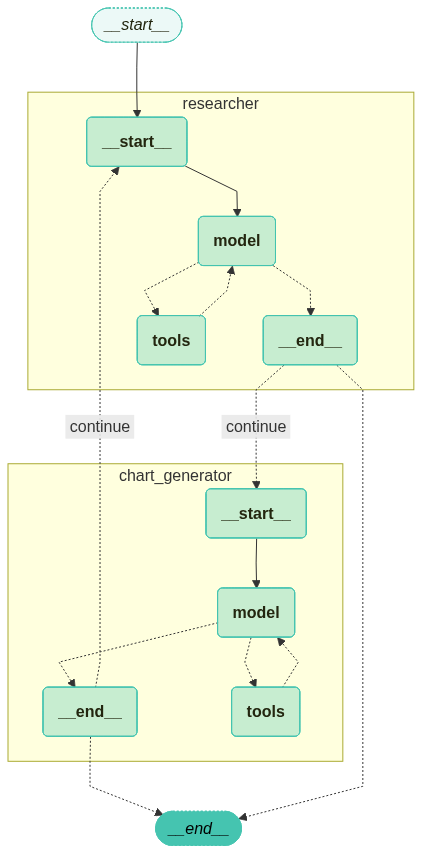

In [12]:
from langchain_teddynote.graphs import visualize_graph

# 그래프 시각화
visualize_graph(app, xray=True)

### 그래프 실행

구성된 그래프를 실행하여 멀티 에이전트 협업이 동작하는 것을 확인합니다. `stream_graph`를 사용하면 실시간 스트리밍 출력을 확인할 수 있습니다.

아래 코드는 그래프를 실행합니다.


🔄 Node: researcher 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
좋습니다! 2010년부터 2025년까지의 대한민국 1인당 GDP 데이터를 수집했습니다. 다음은 정리된 데이터입니다:

## 대한민국 1인당 GDP (2010-2025) - 명목 GDP, 미국 달러 기준

| 연도 | 1인당 GDP (USD) |
|------|-----------------|
| 2010 | $24,071 |
| 2011 | $26,175 |
| 2012 | $26,601 |
| 2013 | $28,449 |
| 2014 | $30,667 |
| 2015 | $30,172 |
| 2016 | $30,832 |
| 2017 | $33,297 |
| 2018 | $35,364 |
| 2019 | $33,827 |
| 2020 | $33,646 |
| 2021 | $37,518 |
| 2022 | $34,822 |
| 2023 | $35,674 |
| 2024 | $36,239 |
| 2025 | $35,960 (추정) |

**주요 특징:**
- 2010년 약 $24,071에서 시작하여 전반적으로 상승 추세
- 2021년 $37,518로 최고점 기록
- 환율 변동과 경제 상황에 따라 등락이 있었음
- 2022년 강달러 영향으로 하락
- 2025년은 추정치

이제 차트 생성 전문가에게 이 데이터를 시각화하도록 요청하겠습니다.

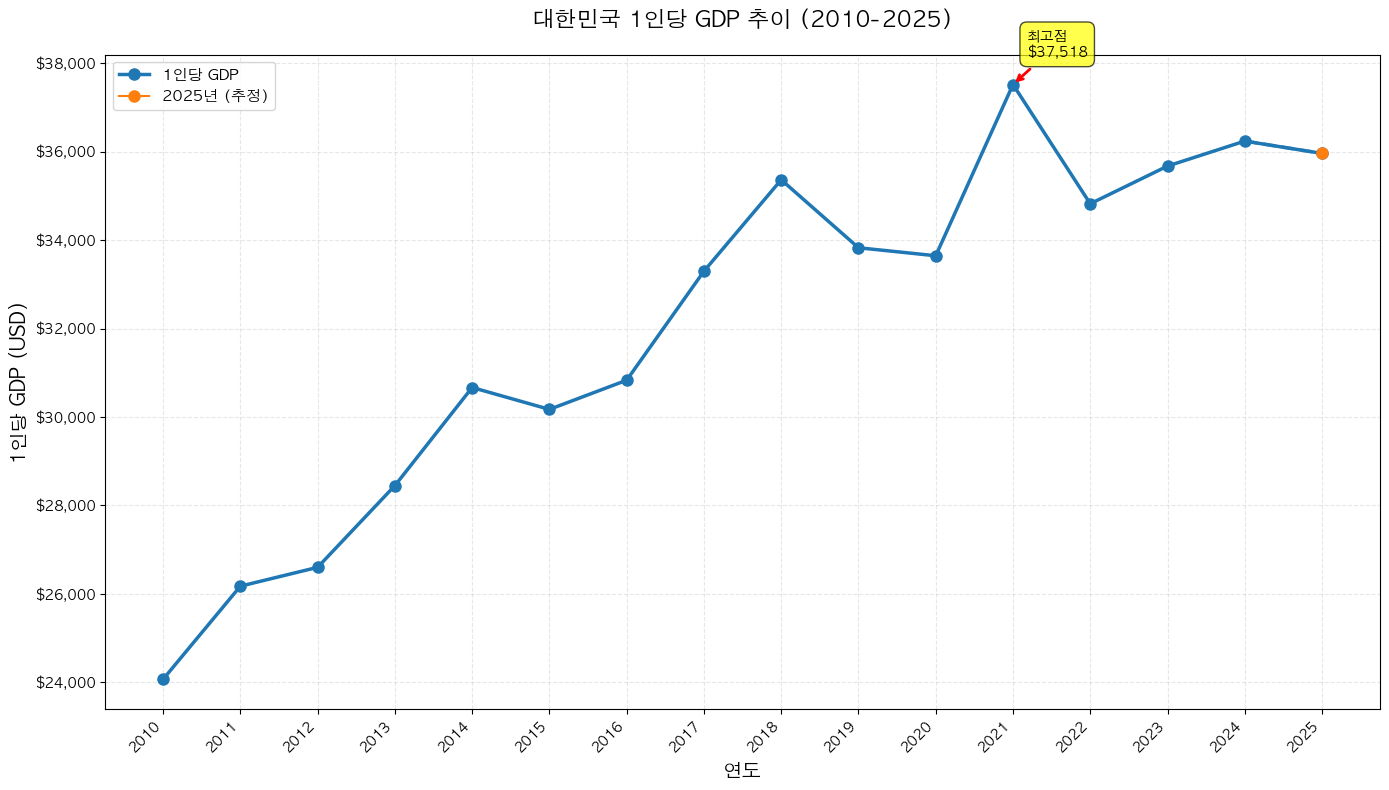


🔄 Node: chart_generator 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
대한민국의 2010년부터 2025년까지의 1인당 GDP 추이를 그래프로 시각화해드리겠습니다.Successfully executed:
```python

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform
import numpy as np

##### 폰트 설정 #####
# OS 판단
current_os = platform.system()

if current_os == "Windows":
    # Windows 환경 폰트 설정
    font_path = "C:/Windows/Fonts/malgun.ttf"  # 맑은 고딕 폰트 경로
    fontprop = fm.FontProperties(fname=font_path, size=12)
    plt.rc("font", family=fontprop.get_name())
elif current_os == "Darwin":  # macOS
    # Mac 환경 폰트 설정
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux 등 기타 OS
    # 기본 한글 폰트 설정 시도
    try:
        plt.rcParams["font.family"] = "NanumGothic"
    except:
        print("한글 폰트를 찾을 수 없습니다. 시스템 기본 폰트를 사용합니다.")

##### 마이너스 폰트 깨짐 방지 #####
plt.rcParams["axes.unicode_minus"] = False  # 마이너스 폰트 깨짐 방지

# 데이터 준비
years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 202

In [13]:
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage
from langchain_teddynote.messages import stream_graph

# config 설정 (재귀 최대 횟수, thread_id)
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": "thread-1"})

# 질문 입력
inputs = {
    "messages": [
        HumanMessage(
            content="2010년 ~ 2025년까지의 대한민국의 1인당 GDP 추이를 그래프로 시각화 해주세요."
        )
    ],
}

# 그래프 스트리밍 실행
stream_graph(app, inputs=inputs, config=config)

## 정리

이번 튜토리얼에서는 LangGraph를 활용하여 멀티 에이전트 협업 네트워크를 구축하는 방법을 학습했습니다. 주요 내용을 정리하면 다음과 같습니다.

- **멀티 에이전트 네트워크**: 복잡한 작업을 여러 전문 에이전트로 분할하여 처리하는 "분할 정복" 아키텍처입니다.
- **에이전트 생성**: `create_agent` 함수를 사용하여 모델과 도구를 결합한 에이전트를 생성하고, 시스템 프롬프트로 역할을 정의합니다.
- **라우터 함수**: 에이전트 출력에 "FINAL ANSWER"가 포함되었는지 확인하여 그래프 종료 또는 다른 에이전트로의 전환을 결정합니다.
- **조건부 엣지**: `add_conditional_edges`를 사용하여 에이전트 간 순환 흐름을 구성하고, 동적으로 다음 노드를 결정합니다.

### 추가 학습 자료

더 깊이 있는 학습을 원한다면 아래 공식 문서를 참고하세요.

- [LangChain Multi-Agent](https://docs.langchain.com/oss/python/langchain/multi-agent/)
- [LangGraph Graph API](https://docs.langchain.com/oss/python/langgraph/graph-api)